# Drivers 09 — Earthquakes (GeoNet)
25,554 M≥4 events (1901–2026) from the GeoNet QuakeSearch API. Per-transect
(computed on 2 km alongshore blocks): counts within 50/100 km, distance to
nearest M≥6.5, a magnitude-energy distance-weighted shaking index, and a
coseismic flag (≤50 km from a shallow M≥7 within the NZCCD record period).
Note the 1931 Napier M7.8 predates the GeoNet digital catalogue's reliable
early coverage — completeness before ~1940 is limited.

In [1]:
import pandas as pd
from drivers import common

In [2]:
import pandas as pd
from drivers import common

path = common.DRIVER_DATA / "d09_quakes.parquet"
if not path.exists():
    from drivers.d09_quakes import build
    df = build()
else:
    df = pd.read_parquet(path)
    print(f"loaded cached {path.name}: {len(df):,} rows")
df.head()

loaded cached d09_quakes.parquet: 228,538 rows


,UniqueID,n_M4_50km,n_M5_50km,n_M6_100km,dist_M65_km,shaking_idx,coseismic_flag
0,203054437032,0,0,1,129.581096,7.622094,False
1,203054438164,0,0,1,129.581096,7.622094,False
2,203054439252,0,0,1,129.581096,7.622094,False
3,203054440300,0,0,1,129.581096,7.622094,False
4,203054441325,0,0,1,129.581096,7.622094,False


In [3]:
df.describe(include='all').T.head(40)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UniqueID,228538.0,NaN,NaN,NaN,139300979226.829895,48710893827.675819,100000185990.0,100422347904.25,100584280354.0,200240849080.75,203057476049.0
n_M4_50km,228538.0,NaN,NaN,NaN,202.61683,291.887391,0.0,5.0,106.0,294.0,1656.0
n_M5_50km,228538.0,NaN,NaN,NaN,17.931241,25.532373,0.0,0.0,9.0,26.0,139.0
n_M6_100km,228538.0,NaN,NaN,NaN,5.310942,5.602277,0.0,0.0,4.0,9.0,23.0
dist_M65_km,228538.0,NaN,NaN,NaN,135.499848,114.672133,0.56605,46.856312,97.441717,200.803654,464.016478
shaking_idx,228538.0,NaN,NaN,NaN,7.486162,0.417398,6.688034,7.242977,7.494918,7.750721,8.729784
coseismic_flag,228538,2,False,213043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


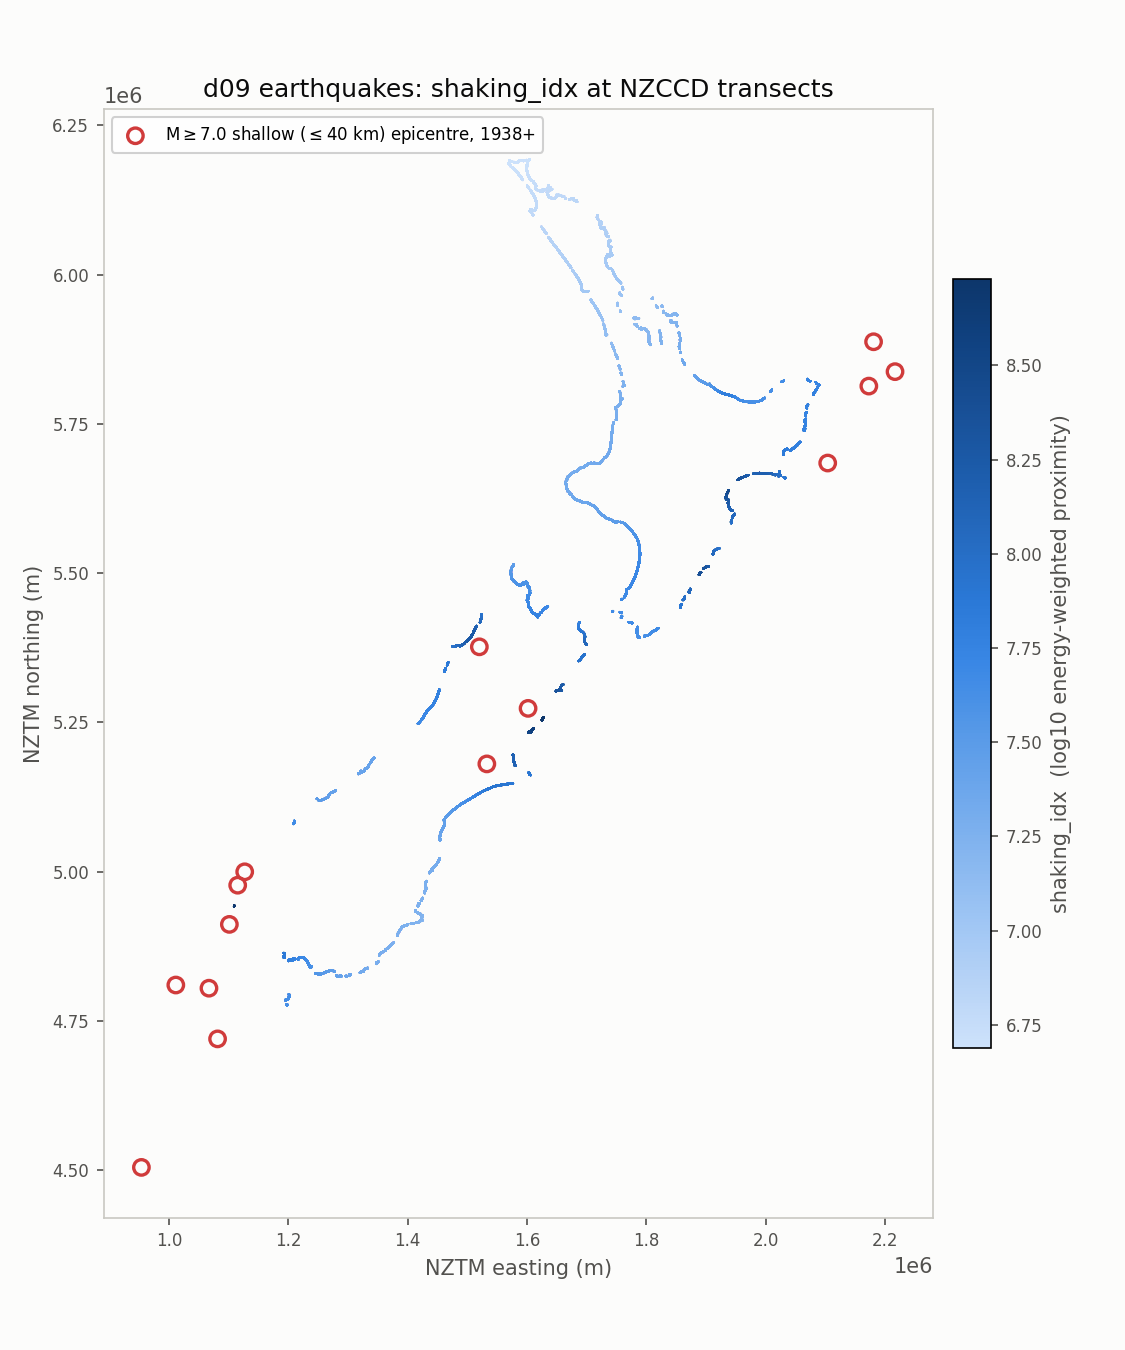

In [4]:
from IPython.display import Image, display
from drivers.common import QA_DIR
p = QA_DIR / 'd09_shaking_map.png'
display(Image(str(p), width=760)) if p.exists() else print('missing d09_shaking_map.png')